# WebSky Data Analysis

### Previous

In [1]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import gc
import os
import math
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *
from scipy import stats
from scipy import odr
from scipy.signal import windows

from astropy.wcs import WCS
from astropy.io import fits
from reproject import reproject_from_healpix

import datetime

print("Packages imported successfully")

Packages imported successfully


In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel
if 'muy_hat_harmonic' in locals():
    del muy_hat_harmonic
if 'muy_hat_pixel' in locals():
    del muy_hat_pixel
if 'residuals_harmonic' in locals():
    del residuals_harmonic
if 'residuals_pixel' in locals():
    del residuals_pixel
if 'cov_matrix' in locals():
    del cov_matrix
if 'cov_matrix_inv' in locals():
    del cov_matrix_inv
if 'weights' in locals():
    del weights

plt.close('all') # Tanca absolutament tots els renders de fons vells abans de fer un plot nou
gc.collect() # Manually trigger memory cleanup

69

### Check frequencies and mu value!

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Zegeye paper frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270]

# PICO paper frequencies in GHz
PICO_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799] # PICO frequencies in GHz

# Choose which frequency set to use for the analysis
#freq_str_name = "Zegeye" # "Planck", "Zegeye", or "PICO"
freq_str_name = "PICO" # "Planck", "Zegeye", or "PICO"

# FWHM
FWHM = [38.4, 32.0, 28.3, 23.6, 22.2, 18.4, 12.8, 10.7, 9.5, 7.9, 7.4, 6.2, 4.3, 3.6, 3.2, 2.6, 2.5, 2.1, 1.5, 1.3, 1.1] # arcmin

# Reference noise
noise = [16.9, 11.8, 8.1, 5.7, 5.8, 4.1, 3.8, 2.9, 2.0, 1.6, 1.6, 1.3, 2.6, 3.0, 2.1, 2.9, 3.5, 7.4, 34.6, 144, 896] # uK-arcmin, from PICO paper
#base_sensitivity_uk_arcmin = 30.0
#base_sensitivity_uk_arcmin = 2.0
#base_sensitivity_uk_arcmin = 0.61
#base_sensitivity_uk_arcmin = 0.2
#base_sensitivity_uk_arcmin = 0.02

# Let's create a dataframe to hold the frequencies, FWHM, and noise values for easier handling
freq_df = pd.DataFrame({
    'Frequency (GHz)': PICO_frequencies,
    'FWHM (arcmin)': FWHM[:len(PICO_frequencies)], # Ensure we only take the FWHM values corresponding to the selected frequencies
    'Noise (uK-arcmin)': noise[:len(PICO_frequencies)] # Ensure we only take the noise values corresponding to the selected frequencies
})

# Theoretical (LCDM) mu-distortion value
#mu = 5e-4
mu = 2e-4
#mu = 5e-5
#mu = 2e-5
#mu = 2e-8
#mu = 0e+00

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

print("----------------------------------------")
print("------------ Configuration -------------")
print("----------------------------------------")
print(f"Nside: {nside_work}")
print(rf"T_CMB: {T_cmb_muK:.0f} muK")
print(f"Theoretical mu-distortion value: {mu:.0e}")
print(f"Pixel area at Nside {nside_work}: {pixel_area_arcmin2:.2f} arcmin^2")

# Let's show the dataframe as well
# Transpose it for horizontal display
df_horizontal_freq = freq_df.set_index('Frequency (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("\nFrequency Configuration:")
print(df_horizontal_freq)
print("----------------------------------------")
print("------- Date:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),"------")
print("----------------------------------------")


----------------------------------------
------------ Configuration -------------
----------------------------------------
Nside: 2048
T_CMB: 2725500 muK
Theoretical mu-distortion value: 2e-04
Pixel area at Nside 2048: 2.95 arcmin^2

Frequency Configuration:
Frequency (GHz)     21    25    30    36    43    52    62    75   90   108  129  155  186  223  268  321  385  462   555    666    799
FWHM (arcmin)      38.4  32.0  28.3  23.6  22.2  18.4  12.8  10.7  9.5  7.9  7.4  6.2  4.3  3.6  3.2  2.6  2.5  2.1   1.5    1.3    1.1
Noise (uK-arcmin)  16.9  11.8   8.1   5.7   5.8   4.1   3.8   2.9  2.0  1.6  1.6  1.3  2.6  3.0  2.1  2.9  3.5  7.4  34.6  144.0  896.0
----------------------------------------
------- Date: 2026-07-08 13:19:04 ------
----------------------------------------


In [4]:
# Aurlien PICO Instrument Parameters (21 channels)
pico_specs = {
    21:  {"fwhm_arcmin": 38.4, "sigma_uk_arcmin": 16.9},
    25:  {"fwhm_arcmin": 32.0, "sigma_uk_arcmin": 11.8},
    30:  {"fwhm_arcmin": 28.3, "sigma_uk_arcmin": 8.1},
    36:  {"fwhm_arcmin": 23.6, "sigma_uk_arcmin": 5.7},
    43:  {"fwhm_arcmin": 22.2, "sigma_uk_arcmin": 5.8},
    52:  {"fwhm_arcmin": 18.4, "sigma_uk_arcmin": 4.1},
    62:  {"fwhm_arcmin": 12.8, "sigma_uk_arcmin": 3.8},
    75:  {"fwhm_arcmin": 10.7, "sigma_uk_arcmin": 2.9},
    90:  {"fwhm_arcmin": 9.5,  "sigma_uk_arcmin": 2.0},
    108: {"fwhm_arcmin": 7.9,  "sigma_uk_arcmin": 1.6},
    129: {"fwhm_arcmin": 7.4,  "sigma_uk_arcmin": 1.6},
    155: {"fwhm_arcmin": 6.2,  "sigma_uk_arcmin": 1.3},
    186: {"fwhm_arcmin": 4.3,  "sigma_uk_arcmin": 2.6},
    223: {"fwhm_arcmin": 3.6,  "sigma_uk_arcmin": 3.0},
    268: {"fwhm_arcmin": 3.2,  "sigma_uk_arcmin": 2.1},
    321: {"fwhm_arcmin": 2.6,  "sigma_uk_arcmin": 2.9},
    385: {"fwhm_arcmin": 2.5,  "sigma_uk_arcmin": 3.5},
    462: {"fwhm_arcmin": 2.1,  "sigma_uk_arcmin": 7.4},
    555: {"fwhm_arcmin": 1.5,  "sigma_uk_arcmin": 34.6},
    666: {"fwhm_arcmin": 1.3,  "sigma_uk_arcmin": 144.0},
    799: {"fwhm_arcmin": 1.1,  "sigma_uk_arcmin": 896.0}
}

In [5]:
# Real PICO Instrument Parameters (21 channels)
pico_specs_2 = {
    21:  {"fwhm_arcmin": 38.4, "sigma_uk_arcmin": 23.8},
    25:  {"fwhm_arcmin": 32.0, "sigma_uk_arcmin": 19.4},
    30:  {"fwhm_arcmin": 28.3, "sigma_uk_arcmin": 15.0},
    36:  {"fwhm_arcmin": 23.6, "sigma_uk_arcmin": 10.6},
    43:  {"fwhm_arcmin": 22.2, "sigma_uk_arcmin": 8.4},
    52:  {"fwhm_arcmin": 18.4, "sigma_uk_arcmin": 7.0},
    62:  {"fwhm_arcmin": 12.8, "sigma_uk_arcmin": 6.1},
    75:  {"fwhm_arcmin": 10.7, "sigma_uk_arcmin": 5.3},
    90:  {"fwhm_arcmin": 9.5,  "sigma_uk_arcmin": 4.1},
    108: {"fwhm_arcmin": 7.9,  "sigma_uk_arcmin": 3.2},
    129: {"fwhm_arcmin": 7.4,  "sigma_uk_arcmin": 2.5},
    155: {"fwhm_arcmin": 6.2,  "sigma_uk_arcmin": 2.2},
    186: {"fwhm_arcmin": 4.3,  "sigma_uk_arcmin": 4.0},
    223: {"fwhm_arcmin": 3.6,  "sigma_uk_arcmin": 4.7},
    268: {"fwhm_arcmin": 3.2,  "sigma_uk_arcmin": 4.4},
    321: {"fwhm_arcmin": 2.6,  "sigma_uk_arcmin": 5.3},
    385: {"fwhm_arcmin": 2.5,  "sigma_uk_arcmin": 8.1},
    462: {"fwhm_arcmin": 2.1,  "sigma_uk_arcmin": 14.8},
    555: {"fwhm_arcmin": 1.5,  "sigma_uk_arcmin": 41.5},
    666: {"fwhm_arcmin": 1.3,  "sigma_uk_arcmin": 94.6},
    799: {"fwhm_arcmin": 1.1,  "sigma_uk_arcmin": 258.0}
}

### Scaling functions

In [4]:
### Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

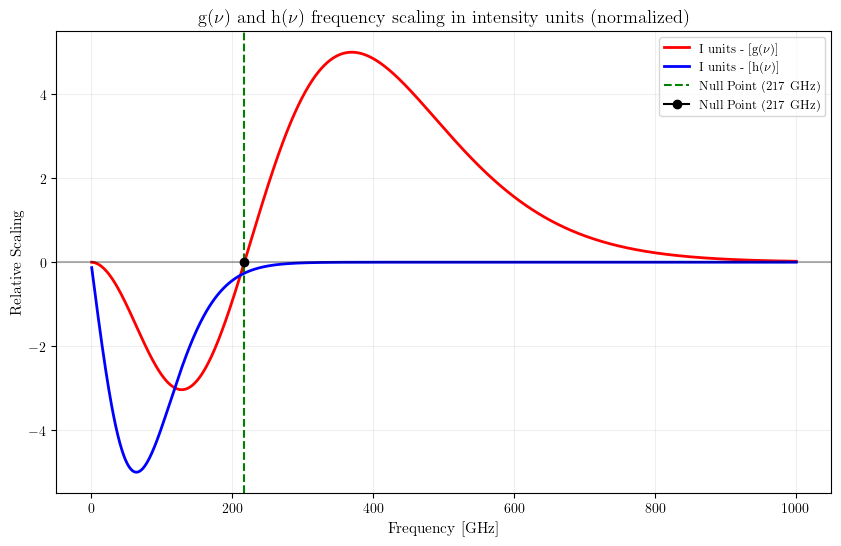

In [7]:
### Compare the tSZ frequency scalings in Intensity and Temperature units ###

def get_tsz_g_intensity_scaling(nu_ghz):
    """The Intensity distortion shape (MJy/sr units)"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_g(nu_ghz)

def get_tsz_h_intensity_scaling(nu_ghz):
    """The Taylor expansion function in Intensity units"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_h(nu_ghz)

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz
PICO_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799] # PICO frequencies in GHz

g = get_tsz_g(nu)
h = get_tsz_h(nu)

g_int = get_tsz_g_intensity_scaling(nu)
h_int = get_tsz_h_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_norm = g / np.max(np.abs(g))
h_norm = h / np.max(np.abs(h))

g_int_norm = g_int / np.max(np.abs(g_int))
h_int_norm = h_int / np.max(np.abs(h_int))

# --- LATEX ARCHITECTURE STYLE ENGINE ---
plt.rcParams.update({
    "text.usetex": True,                 # Force active LaTeX font engine
    "font.family": "serif",              # Modern Roman font family matching thesis text
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Plotting
plt.figure(figsize=(10, 6))

# Scalings for Temperature and Intensity
#plt.plot(nu, g_norm * 5, label=rf"T units  - [g($\nu$)]", color='orange', lw=2, linestyle='-.')
#plt.plot(nu, h_norm * 5, label=rf"T units  - [h($\nu$)]", color='cyan', lw=2, linestyle='-.')
plt.plot(nu, g_int_norm * 5, label=rf"I units  - [g($\nu$)]", color='red', lw=2, linestyle='-')
plt.plot(nu, h_int_norm * 5, label=rf"I units  - [h($\nu$)]", color='blue', lw=2, linestyle='-')

# Null Point and baseline
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(217, color='green', linestyle='--', label='Null Point (217 GHz)')
plt.plot(217,0, marker='o', color='black', label='Null Point (217 GHz)')

# Final touches
#plt.title(rf"g($\nu$) and h($\nu$) frequency scaling: Temperature and Intensity Units (Normalized)")
plt.title(rf"g($\nu$) and h($\nu$) frequency scaling in intensity units (normalized)")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Relative Scaling")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/Scaling_Functions/Intensity_Scaling.pdf", bbox_inches='tight', dpi=300)
plt.show()

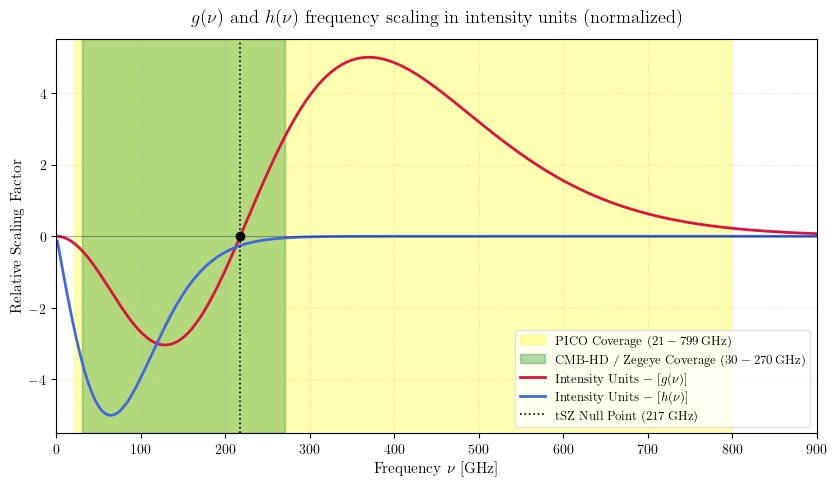

In [9]:
### IMPROVED PLOT ###

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] 
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # CMB-HD configuration
PICO_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799]

# Calculate scalings
g_int = get_tsz_g_intensity_scaling(nu)
h_int = get_tsz_h_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_int_norm = g_int / np.max(np.abs(g_int))
h_int_norm = h_int / np.max(np.abs(h_int))

# --- LATEX ARCHITECTURE STYLE ENGINE ---
plt.rcParams.update({
    "text.usetex": True,                 # Force active LaTeX font engine
    "font.family": "serif",              # Modern Roman font family matching thesis text
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Plotting setup
fig, ax = plt.subplots(figsize=(8.5, 5))

# 1. OVERPLOT THE EXPERIMENT FREQUENCY COVERAGE BANDS (Background layers)
# We span from the minimum channel to the maximum channel for each experiment configuration
ax.axvspan(min(PICO_frequencies), max(PICO_frequencies), 
           color='yellow', alpha=0.3, label=r'PICO Coverage ($21 - 799\,\mathrm{GHz}$)')

ax.axvspan(min(zegeye_frequencies), max(zegeye_frequencies), 
           color='green', alpha=0.3, label=r'CMB-HD / Zegeye Coverage ($30 - 270\,\mathrm{GHz}$)')

# 2. PLOT THE SPECTRAL FUNCTIONS
ax.plot(nu, g_int_norm * 5, label=r'Intensity Units $-\ [g(\nu)]$', color='crimson', lw=2, linestyle='-')
ax.plot(nu, h_int_norm * 5, label=r'Intensity Units $-\ [h(\nu)]$', color='royalblue', lw=2, linestyle='-')

# 3. CRITICAL BASELINES AND REFERENCE POINTS
ax.axhline(0, color='black', alpha=0.3, lw=0.8)
ax.axvline(217, color='black', linestyle=':', lw=1.2, label=r'tSZ Null Point ($217\,\mathrm{GHz}$)')
ax.plot(217, 0, marker='o', color='black', markersize=6)

# 4. RE-AXIS BOUNDARIES FOR CLEAN VISUALS
ax.set_xlim(0, 900)
ax.set_ylim(-5.5, 5.5)

# 5. LABELS AND THESIS POLISHING
ax.set_title(r'$g(\nu)$ and $h(\nu)$ frequency scaling in intensity units (normalized)', pad=12)
ax.set_xlabel(r'Frequency $\nu$ [GHz]')
ax.set_ylabel(r'Relative Scaling Factor')

# Move legend to upper right or use best layout placement
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='gainsboro')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()

# 6. SAVE LOGIC
save_path = "/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/Scaling_Functions/Intensity_and_Temperature_Scalings.pdf"
save_dir = os.path.dirname(save_path)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

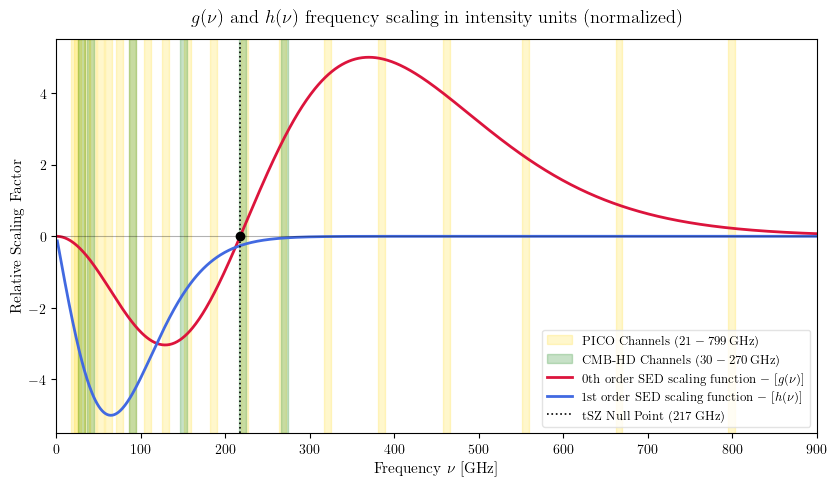

In [10]:
### IMPROVED PLOT WITH DISCRETE CHANNELS ###

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] 
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # CMB-HD configuration
PICO_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799]

# Calculate scalings (Asegúrate de tener definidas estas funciones antes)
g_int = get_tsz_g_intensity_scaling(nu)
h_int = get_tsz_h_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_int_norm = g_int / np.max(np.abs(g_int))
h_int_norm = h_int / np.max(np.abs(h_int))

# --- LATEX ARCHITECTURE STYLE ENGINE ---
plt.rcParams.update({
    "text.usetex": True,                 # Force active LaTeX font engine
    "font.family": "serif",              # Modern Roman font family matching thesis text
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Plotting setup
fig, ax = plt.subplots(figsize=(8.5, 5))

# ============================================================================
# 1. OVERPLOT EXPERIMENT CHANNELS AS INDIVIDUAL TRANSPARENT BANDS
# ============================================================================
# Definim una amplada visual per a les bandes (en GHz). 
# Un valor de 6 a 10 GHz fa que es vegin clares sense xocar gaire entre elles.
bandwidth = 8.0  

# A) PICO Channels (Yellow bands)
for i, freq in enumerate(PICO_frequencies):
    lbl = r'PICO Channels ($21-799\,\mathrm{GHz}$)' if i == 0 else ""
    ax.axvspan(freq - bandwidth/2, freq + bandwidth/2, color='gold', alpha=0.2, label=lbl)

# B) CMB-HD / Zegeye Channels (Green bands)
for i, freq in enumerate(zegeye_frequencies):
    lbl = r'CMB-HD Channels ($30-270\,\mathrm{GHz}$)' if i == 0 else ""
    ax.axvspan(freq - bandwidth/2, freq + bandwidth/2, color='forestgreen', alpha=0.25, label=lbl)

# C) OPCIONAL: Si vols afegir també els de Planck perquè hi són al codi, pots fer:
# for i, freq in enumerate(planck_frequencies):
#     lbl = r'Planck Channels' if i == 0 else ""
#     ax.axvspan(freq - bandwidth/2, freq + bandwidth/2, color='darkorange', alpha=0.15, label=lbl)


# ============================================================================
# 2. PLOT THE SPECTRAL FUNCTIONS
# ============================================================================
ax.plot(nu, g_int_norm * 5, label=r'0th order SED scaling function $-\ [g(\nu)]$', color='crimson', lw=2, linestyle='-')
ax.plot(nu, h_int_norm * 5, label=r'1st order SED scaling function $-\ [h(\nu)]$', color='royalblue', lw=2, linestyle='-')


# ============================================================================
# 3. CRITICAL BASELINES AND REFERENCE POINTS
# ============================================================================
ax.axhline(0, color='black', alpha=0.3, lw=0.8)
ax.axvline(217, color='black', linestyle=':', lw=1.2, label=r'tSZ Null Point ($217\,\mathrm{GHz}$)')
ax.plot(217, 0, marker='o', color='black', markersize=6, zorder=5)


# ============================================================================
# 4. RE-AXIS BOUNDARIES AND LABELS
# ============================================================================
ax.set_xlim(0, 900)
ax.set_ylim(-5.5, 5.5)

ax.set_title(r'$g(\nu)$ and $h(\nu)$ frequency scaling in intensity units (normalized)', pad=12)
ax.set_xlabel(r'Frequency $\nu$ [GHz]')
ax.set_ylabel(r'Relative Scaling Factor')

# Colocamos la leyenda en una zona limpia
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='gainsboro')
#ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()


# ============================================================================
# 5. SAVE LOGIC
# ============================================================================
save_path = "/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/Scaling_Functions/SED_Scaling_Functions.pdf"
save_dir = os.path.dirname(save_path)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

### Data Reading & Writing

In [6]:
### 1. Load WebSky Components --- https://lambda.gsfc.nasa.gov/simulation/mocks_data.html --- CMB in muK units ###

# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/WebSky_CMB_Mocks/'
path_to_processed_maps = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'

# Set your working resolution and corresponding lmax
nside_work = 2048

print("Reading WebSky maps...")

Reading WebSky maps...


In [7]:
### A.1. Load tSZ as y_map ###
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)
print(f"tSZ map loaded and downgraded to Nside {nside_work}")

tSZ map loaded and downgraded to Nside 2048


In [8]:
### A.2. Downgrade and save the tSZ map (y_map) as y_map.fits ###
hp.write_map(path_to_processed_maps + "y_map.fits", y_map, coord='G', overwrite=True, dtype=np.float32)
print(f"tSZ map saved as y_map.fits")

tSZ map saved as y_map.fits


In [9]:
### B.1 Load CMB alms and let it detect the original Lmax, calculate the Lmax of the file data and convert to map ###
# Use return_mmax=True to be extra safe with WebSky's format
alms_cmb, mmax_in = hp.read_alm(path_to_websky + "unlensed_alm.fits", hdu=1, return_mmax=True)

# C. Calculate the Lmax of the file data
lmax_in = hp.Alm.getlmax(len(alms_cmb), mmax_in)

# D. Convert to map. 
# We tell it the ALMs are at 'lmax_in', but we want the result at 'nside_work'
cmb_map = hp.alm2map(alms_cmb, nside=nside_work, lmax=lmax_in, mmax=mmax_in)

print(f"CMB map with mmax_in = {mmax_in} loaded at Nside {nside_work} with Lmax {lmax_in}")

CMB map with mmax_in = 8250 loaded at Nside 2048 with Lmax 8250


In [10]:
### B.2. Save the clean CMB map (in muK) as cmb_map.fits ###
hp.write_map(path_to_processed_maps + "cmb_map.fits", cmb_map, coord='G', overwrite=True, dtype=np.float32)
print(f"CMB map saved as cmb_map.fits")

CMB map saved as cmb_map.fits


# Data Cube generation

---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 2e-4
- 0.2 uK·arcmin
- Zegeye
- 10/05
- 32 bits
---

In [34]:
### 2. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_2e-04.fits'.
Data Cube 32 (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_2e-04.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 2e-04
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-10 19:41:44
----------------------------------------


In [ ]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -9.3866e-02 uK
mu-tSZ Min value = -1.7712e-05 uK
---------------------------------
Noise Max value = -7.3516e-02 uK
Noise Min value = -1.0624e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 5e-4
- 0.2 uK·arcmin
- Zegeye
- 11/05
- 32 bits
---

In [11]:
### 2.1. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_5e-04.fits'.
Data Cube 32 (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_5e-04.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 5e-04
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-11 12:10:46
----------------------------------------


In [12]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -2.3466e-01 uK
mu-tSZ Min value = -4.4280e-05 uK
---------------------------------
Noise Max value = -7.7538e-02 uK
Noise Min value = -1.0625e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 2e-5
- 0.2 uK·arcmin
- Zegeye
- 10/05
- 32 bits
---

In [ ]:
### 2.2. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_2e-05.fits'.
Data Cube 32 (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_2e-05.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 2e-05
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-10 19:52:00
----------------------------------------


In [11]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -9.3866e-03 uK
mu-tSZ Min value = -1.7712e-06 uK
---------------------------------
Noise Max value = -8.0640e-02 uK
Noise Min value = -1.0625e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 5e-5
- 0.2 uK·arcmin
- Zegeye
- 11/05
- 32 bits
---

In [11]:
### 2.3. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 0.1164 uK


Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_5e-05.fits'.
Data Cube 32 (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_5e-05.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 5e-05
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-11 17:08:57
----------------------------------------


In [12]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------


CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -2.3466e-02 uK
mu-tSZ Min value = -4.4280e-06 uK
---------------------------------
Noise Max value = -1.4257e-02 uK
Noise Min value = -1.0623e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 2e-4
- 0.2 uK·arcmin
- PICO
- 06/06
- 32 bits
---

In [14]:
### 2.6. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(PICO_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in PICO_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {PICO_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 21  GHz, Noise per pixel: 0.1164 uK
Frequency: 25  GHz, Noise per pixel: 0.1164 uK
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 36  GHz, Noise per pixel: 0.1164 uK
Frequency: 43  GHz, Noise per pixel: 0.1164 uK
Frequency: 52  GHz, Noise per pixel: 0.1164 uK
Frequency: 62  GHz, Noise per pixel: 0.1164 uK
Frequency: 75  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 108 GHz, Noise per pixel: 0.1164 uK
Frequency: 129 GHz, Noise per pixel: 0.1164 uK
Frequency: 155 GHz, Noise per pixel: 0.1164 uK
Frequency: 186 GHz, Noise per pixel: 0.1164 uK
Frequency: 223 GHz, Noise per pixel: 0.1164 uK
Frequency: 268 GHz, Noise per pixel: 0.1164 uK
Frequency: 321 GHz, Noise per pixel: 0.1164 uK
Frequency: 385 GHz, Noise per pixel: 0.1164 uK
Frequency: 462 GHz, Noise per pixel: 0.1164 uK
Frequency: 555 GHz, Noise per pixel: 0.1164 uK
Frequency: 666 GHz, Noise per pixel:

In [15]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(PICO_frequencies[0])
h0 = get_tsz_h(PICO_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------


CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0287e-01 uK
tSZ Min value = -1.0751e+03 uK
---------------------------------
mu-tSZ Max value = -1.4052e-01 uK
mu-tSZ Min value = -2.6515e-05 uK
---------------------------------
Noise Max value = 1.0789e-01 uK
Noise Min value = -1.0752e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 2e-4
- 0.61 uK·arcmin
- PICO
- 07/06
- 32 bits
---

In [11]:
### 2.7. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(PICO_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in PICO_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print(rf"Data Cube 32 (muK units) saved successfully as 'data_cube_32_{len(PICO_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(rf"base sensitivity = {base_sensitivity_uk_arcmin} uK-arcmin")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {PICO_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 21  GHz, Noise per pixel: 0.3551 uK
Frequency: 25  GHz, Noise per pixel: 0.3551 uK
Frequency: 30  GHz, Noise per pixel: 0.3551 uK
Frequency: 36  GHz, Noise per pixel: 0.3551 uK
Frequency: 43  GHz, Noise per pixel: 0.3551 uK
Frequency: 52  GHz, Noise per pixel: 0.3551 uK
Frequency: 62  GHz, Noise per pixel: 0.3551 uK
Frequency: 75  GHz, Noise per pixel: 0.3551 uK
Frequency: 90  GHz, Noise per pixel: 0.3551 uK
Frequency: 108 GHz, Noise per pixel: 0.3551 uK
Frequency: 129 GHz, Noise per pixel: 0.3551 uK
Frequency: 155 GHz, Noise per pixel: 0.3551 uK
Frequency: 186 GHz, Noise per pixel: 0.3551 uK
Frequency: 223 GHz, Noise per pixel: 0.3551 uK
Frequency: 268 GHz, Noise per pixel: 0.3551 uK
Frequency: 321 GHz, Noise per pixel: 0.3551 uK
Frequency: 385 GHz, Noise per pixel: 0.3551 uK
Frequency: 462 GHz, Noise per pixel: 0.3551 uK
Frequency: 555 GHz, Noise per pixel: 0.3551 uK
Frequency: 666 GHz, Noise per pixel:

In [12]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(PICO_frequencies[0])
h0 = get_tsz_h(PICO_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0287e-01 uK
tSZ Min value = -1.0751e+03 uK
---------------------------------
mu-tSZ Max value = -1.4052e-01 uK
mu-tSZ Min value = -2.6515e-05 uK
---------------------------------
Noise Max value = 8.5299e-01 uK
Noise Min value = -1.0752e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- 2e-4
- Channel dependent uK·arcmin
- PICO
- 02/07
- 32 bits
---

In [11]:
### 2.9. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a superposition of layers ###

# 1. Base Resolution Parameters
nside_work = 2048
npix = hp.nside2npix(nside_work)

# Calculate the exact pixel area in arcmin^2 dynamically
pixel_area_sr = hp.nside2pixarea(nside_work)
pixel_area_arcmin2 = pixel_area_sr * (180 * 60 / np.pi)**2 
print(f"Working pixel area at Nside={nside_work}: {pixel_area_arcmin2:.4f} arcmin^2")

# 2. Allocate the 21-channel Data Cube structural array
# Shape: (21, 50331648), pre-allocated to float32 to maximize your laptop's RAM efficiency
PICO_frequencies = sorted(list(pico_specs.keys()))
data_cube_pico = np.zeros((len(PICO_frequencies), npix), dtype=np.float32)

print("\n--- Generating Real PICO Data Cube Layers ---")

for idx, nu in enumerate(PICO_frequencies):
    print(f"Processing Channel: {nu} GHz...")
    
    # Extract the scaling components from your notebook definitions
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Core Signal Combination: CMB + tSZ + mu-distortion
    signal_layer = cmb_map + (g_nu * y_map * T_cmb_muK) + (mu * h_nu * y_map * T_cmb_muK)
    
    # 3. CHANNEL-DEPENDENT NOISE INJECTION
    sens_uk_arcmin = pico_specs[nu]["sigma_uk_arcmin"]
    
    # Calculate the exact standard deviation per pixel for this channel
    sigma_pixel = sens_uk_arcmin / np.sqrt(pixel_area_arcmin2)
    
    # Generate Gaussian white noise for this channel matching the pixel grid
    noise_layer = np.random.normal(0.0, sigma_pixel, size=npix).astype(np.float32)
    print(noise_layer.std(), sigma_pixel)
    
    # Store combined matrix row inside the data cube
    data_cube_pico[idx, :] = signal_layer + noise_layer
    
    # Keep the laptop's unified memory cache clean on each channel iteration
    gc.collect()


# --- FIXED: Link the saving function directly to the filled data_cube_pico array ---
print("Saving data_cube_pico to FITS...")
output_filename = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(PICO_frequencies)}freq_PICO_ch_{mu:.0e}.fits"

hp.write_map(output_filename, data_cube_pico, 
             coord='G', column_names=[f"freq_{f}" for f in PICO_frequencies],
             overwrite=True, dtype=np.float32)

# Point your legacy variable name to your new matrix so it doesn't break your downstream cells
data_cube_32 = data_cube_pico

print(f"Data Cube (muK units) saved successfully as '{os.path.basename(output_filename)}'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(rf"Instrument Configuration: PICO Channel-Dependent Noise")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")

# Clean up horizontal dataframe visualization prints
df_horizontal_freq = freq_df.set_index('Frequency (GHz)').T if 'freq_df' in locals() else None
if df_horizontal_freq is not None:
    pd.set_option('display.expand_frame_repr', False) 
    pd.set_option('display.max_columns', None)
    print("\nFrequency Configuration:")
    print(df_horizontal_freq)
    
import datetime
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions!

Working pixel area at Nside=2048: 2.9506 arcmin^2

--- Generating Real PICO Data Cube Layers ---
Processing Channel: 21 GHz...
9.838622 9.83849037613264
Processing Channel: 25 GHz...
6.870011 6.869478487477228
Processing Channel: 30 GHz...
4.716261 4.715489470217419
Processing Channel: 36 GHz...
3.3186336 3.3183074049678134
Processing Channel: 43 GHz...
3.3762932 3.376523324353214
Processing Channel: 52 GHz...
2.3869493 2.3868526948014095
Processing Channel: 62 GHz...
2.2119687 2.212204936645209
Processing Channel: 75 GHz...
1.6884334 1.688261662176607
Processing Channel: 90 GHz...
1.1643797 1.1643183877080048
Processing Channel: 108 GHz...
0.93128353 0.9314547101664038
Processing Channel: 129 GHz...
0.9313903 0.9314547101664038
Processing Channel: 155 GHz...
0.75667626 0.7568069520102031
Processing Channel: 186 GHz...
1.5136198 1.5136139040204062
Processing Channel: 223 GHz...
1.7462115 1.746477581562007
Processing Channel: 268 GHz...
1.2227521 1.222534307093405
Processing Channel: 32

In [13]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")
print(f"mu = {mu}")
print("---------------------------------")


# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(PICO_frequencies[0])
h0 = get_tsz_h(PICO_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
mu = 0.0002
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0287e-01 uK
tSZ Min value = -1.0751e+03 uK
---------------------------------
mu-tSZ Max value = -1.4052e-01 uK
mu-tSZ Min value = -2.6515e-05 uK
---------------------------------
Noise Max value = 5.8594e+01 uK
Noise Min value = -1.0566e+03 uK
---------------------------------


---
# 4 layers: CMB + tSZ + mu-distorted tSZ + noise

Change mu, noise, frequencies and date every time you generate a new data_cube:

- $\mu$ = 2e-8
- 2 uK·arcmin
- Planck
- 09/04
- 64 bits
---

In [ ]:
### 3. Create the noise and finally the data_cube_64 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_64 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map + signal_mu_tsz
    data_cube_64.append(total_map)

data_cube_64 = np.array(data_cube_64, dtype=np.float64) # Convert to numpy array for easier handling and ensure it's in float64 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_64 to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_64_9freq.fits", data_cube_64, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float64)

print("Data Cube (muK units) saved successfully as 'data_cube_64_9freq.fits'.")

# Now 'data_cube_64' (muK units) is ready for your ILC functions! 

## Checking $y$ \& $\mu y$ correlation

---
# 3 layers: CMB + tSZ + noise

CHANGE $\mu$, base sensitiviy, frequencies, date and bits EVERY time you generate a new data_cube:

- $\mu$ = 0
- 0.2 uK·arcmin
- Zegeye
- 18/05
- 32 bits
---

In [ ]:
### 2.4. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units ### SHOULD BE NULL IN THIS CASE
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + signal_mu_tsz + noise_map
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(zegeye_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_0e+00.fits'.
Data Cube 32 (muK units) saved successfully as 'data_cube_32_6freq_0.2muK_0e+00.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 0e+00
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-18 21:03:37
----------------------------------------


In [11]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -0.0000e+00 uK
mu-tSZ Min value = -0.0000e+00 uK
---------------------------------
Noise Max value = -1.8466e-02 uK
Noise Min value = -1.0622e+03 uK
---------------------------------


---
# 3 layers: CMB + tSZ + noise

CHANGE $\mu$, base sensitiviy, frequencies, date and bits EVERY time you generate a new data_cube:

- $\mu$ = 0
- 0.2 uK·arcmin
- PICO
- 27/05
- 32 bits
---

In [11]:
### 2.5. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers --- PICO ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz
pico_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799] # PICO frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(pico_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    #signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units ### SHOULD BE NULL IN THIS CASE
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map# + signal_mu_tsz
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(pico_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in pico_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(pico_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {pico_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 21  GHz, Noise per pixel: 0.1164 uK
Frequency: 25  GHz, Noise per pixel: 0.1164 uK
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 36  GHz, Noise per pixel: 0.1164 uK
Frequency: 43  GHz, Noise per pixel: 0.1164 uK
Frequency: 52  GHz, Noise per pixel: 0.1164 uK
Frequency: 62  GHz, Noise per pixel: 0.1164 uK
Frequency: 75  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 108 GHz, Noise per pixel: 0.1164 uK
Frequency: 129 GHz, Noise per pixel: 0.1164 uK
Frequency: 155 GHz, Noise per pixel: 0.1164 uK
Frequency: 186 GHz, Noise per pixel: 0.1164 uK
Frequency: 223 GHz, Noise per pixel: 0.1164 uK
Frequency: 268 GHz, Noise per pixel: 0.1164 uK
Frequency: 321 GHz, Noise per pixel: 0.1164 uK
Frequency: 385 GHz, Noise per pixel: 0.1164 uK
Frequency: 462 GHz, Noise per pixel: 0.1164 uK
Frequency: 555 GHz, Noise per pixel: 0.1164 uK
Frequency: 666 GHz, Noise per pixel:

In [13]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -0.0000e+00 uK
mu-tSZ Min value = -0.0000e+00 uK
---------------------------------
Noise Max value = -2.6036e-02 uK
Noise Min value = -1.0751e+03 uK
---------------------------------


---
# 3 layers: CMB + tSZ + noise

CHANGE $\mu$, base sensitiviy, frequencies, date and bits EVERY time you generate a new data_cube:

- $\mu$ = 0
- 0.61 uK·arcmin
- PICO
- 07/06
- 32 bits
---

In [14]:
### 2.8. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers --- PICO ###

mu = 0e+00

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270] # Zegeye paper frequencies in GHz
pico_frequencies = [21, 25, 30, 36, 43, 52, 62, 75, 90, 108, 129, 155, 186, 223, 268, 321, 385, 462, 555, 666, 799] # PICO frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(pico_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # --- FREQUENCY INDEPENDENT NOISE LEVEL ---
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
   
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    #signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units ### SHOULD BE NULL IN THIS CASE
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + mu-distorted tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map# + signal_mu_tsz
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(pico_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in pico_frequencies],
             overwrite=True, dtype=np.float32)

print(f"Data Cube (muK units) saved successfully as 'data_cube_32_{len(pico_frequencies)}freq_{base_sensitivity_uk_arcmin}muK_{mu:.0e}.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(rf"base sensitivity = {base_sensitivity_uk_arcmin} uK-arcmin")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {pico_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 21  GHz, Noise per pixel: 0.3551 uK
Frequency: 25  GHz, Noise per pixel: 0.3551 uK
Frequency: 30  GHz, Noise per pixel: 0.3551 uK
Frequency: 36  GHz, Noise per pixel: 0.3551 uK
Frequency: 43  GHz, Noise per pixel: 0.3551 uK
Frequency: 52  GHz, Noise per pixel: 0.3551 uK
Frequency: 62  GHz, Noise per pixel: 0.3551 uK
Frequency: 75  GHz, Noise per pixel: 0.3551 uK
Frequency: 90  GHz, Noise per pixel: 0.3551 uK
Frequency: 108 GHz, Noise per pixel: 0.3551 uK
Frequency: 129 GHz, Noise per pixel: 0.3551 uK
Frequency: 155 GHz, Noise per pixel: 0.3551 uK
Frequency: 186 GHz, Noise per pixel: 0.3551 uK
Frequency: 223 GHz, Noise per pixel: 0.3551 uK
Frequency: 268 GHz, Noise per pixel: 0.3551 uK
Frequency: 321 GHz, Noise per pixel: 0.3551 uK
Frequency: 385 GHz, Noise per pixel: 0.3551 uK
Frequency: 462 GHz, Noise per pixel: 0.3551 uK
Frequency: 555 GHz, Noise per pixel: 0.3551 uK
Frequency: 666 GHz, Noise per pixel:

In [15]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -0.0000e+00 uK
mu-tSZ Min value = -0.0000e+00 uK
---------------------------------
Noise Max value = 7.9330e-01 uK
Noise Min value = -1.0747e+03 uK
---------------------------------


---
# 3 layers: CMB + tSZ + noise

CHANGE $\mu$, base sensitiviy, frequencies, date and bits EVERY time you generate a new data_cube:

- $\mu$ = 0
- Channel dependent uK·arcmin
- PICO
- 15/06
- 32 bits
---

In [14]:
### 2.10 Create the noise and finally the data_cube_32 (muK units) at different frequencies as a superposition of layers ###

# 1. Base Resolution Parameters
nside_work = 2048
npix = hp.nside2npix(nside_work)

# Calculate the exact pixel area in arcmin^2 dynamically
pixel_area_sr = hp.nside2pixarea(nside_work)
pixel_area_arcmin2 = pixel_area_sr * (180 * 60 / np.pi)**2 
print(f"Working pixel area at Nside={nside_work}: {pixel_area_arcmin2:.4f} arcmin^2")

# 2. Allocate the 21-channel Data Cube structural array
# Shape: (21, 50331648), pre-allocated to float32 to maximize your laptop's RAM efficiency
PICO_frequencies = sorted(list(pico_specs.keys()))
data_cube_pico = np.zeros((len(PICO_frequencies), npix), dtype=np.float32)

print("\n--- Generating Real PICO Data Cube Layers ---")

for idx, nu in enumerate(PICO_frequencies):
    print(f"Processing Channel: {nu} GHz...")
    
    # Extract the scaling components from your notebook definitions
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Core Signal Combination: CMB + tSZ + mu-distortion
    signal_layer = cmb_map + (g_nu * y_map * T_cmb_muK) #+ (mu * h_nu * y_map * T_cmb_muK)
    
    # 3. CHANNEL-DEPENDENT NOISE INJECTION
    sens_uk_arcmin = pico_specs[nu]["sigma_uk_arcmin"]
    
    # Calculate the exact standard deviation per pixel for this channel
    sigma_pixel = sens_uk_arcmin / np.sqrt(pixel_area_arcmin2)
    
    # Generate Gaussian white noise for this channel matching the pixel grid
    noise_layer = np.random.normal(0.0, sigma_pixel, size=npix).astype(np.float32)
    
    # Store combined matrix row inside the data cube
    data_cube_pico[idx, :] = signal_layer + noise_layer
    
    # Keep the laptop's unified memory cache clean on each channel iteration
    gc.collect()


# --- FIXED: Link the saving function directly to the filled data_cube_pico array ---
print("Saving data_cube_pico to FITS...")
output_filename = f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_{len(PICO_frequencies)}freq_PICO_ch_{mu:.0e}.fits"

hp.write_map(output_filename, data_cube_pico, 
             coord='G', column_names=[f"freq_{f}" for f in PICO_frequencies],
             overwrite=True, dtype=np.float32)

# Point your legacy variable name to your new matrix so it doesn't break your downstream cells
data_cube_32 = data_cube_pico

print(f"Data Cube (muK units) saved successfully as '{os.path.basename(output_filename)}'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(rf"Instrument Configuration: PICO Channel-Dependent Noise")
print(f"Data Cube shape (N_freq, N_pix): {data_cube_32.shape}")
print(f"Data Cube dtype: {data_cube_32.dtype}")
print(f"Data Cube memory usage: {data_cube_32.nbytes / 1e6:.2f} MB")

# Clean up horizontal dataframe visualization prints
df_horizontal_freq = freq_df.set_index('Frequency (GHz)').T if 'freq_df' in locals() else None
if df_horizontal_freq is not None:
    pd.set_option('display.expand_frame_repr', False) 
    pd.set_option('display.max_columns', None)
    print("\nFrequency Configuration:")
    print(df_horizontal_freq)
    
import datetime
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube_32' (muK units) is ready for your ILC functions!

Working pixel area at Nside=2048: 2.9506 arcmin^2

--- Generating Real PICO Data Cube Layers ---
Processing Channel: 21 GHz...


Processing Channel: 25 GHz...
Processing Channel: 30 GHz...
Processing Channel: 36 GHz...
Processing Channel: 43 GHz...
Processing Channel: 52 GHz...
Processing Channel: 62 GHz...
Processing Channel: 75 GHz...
Processing Channel: 90 GHz...
Processing Channel: 108 GHz...
Processing Channel: 129 GHz...
Processing Channel: 155 GHz...
Processing Channel: 186 GHz...
Processing Channel: 223 GHz...
Processing Channel: 268 GHz...
Processing Channel: 321 GHz...
Processing Channel: 385 GHz...
Processing Channel: 462 GHz...
Processing Channel: 555 GHz...
Processing Channel: 666 GHz...
Processing Channel: 799 GHz...
Saving data_cube_pico to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_21freq_PICO_ch_0e+00.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 0e+00
Instrument Configuration: PICO Channel-Dependent Noise
Data Cube shape (N_freq, N_pix): (21, 50331648)
Data Cube dtype: float32
Data Cu

In [15]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

print(f"mu value = {mu}")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube_32[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
print("---------------------------------")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
mu value =
---------------------------------
CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -0.0000e+00 uK
mu-tSZ Min value = -0.0000e+00 uK
---------------------------------
Noise Max value = 7.6756e+01 uK
Noise Min value = -1.0750e+03 uK
---------------------------------


---
Change mu, noise and date every time you generate a new data_cube:

2e-8 --- 30.0 uK·arcmin --- Planck --- 07/04

3 layers: CMB + tSZ + noise
---

In [ ]:
### 4. Create the noise and finally the data_cube_no_muy (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(planck_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    #signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(planck_frequencies)}freq_no_muy_{base_sensitivity_uk_arcmin}muK.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in planck_frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube '$\mu y$-free' (muK units), $\mu$={mu:.0e}$ saved successfully as 'data_cube_{len(planck_frequencies)}freq_no_muy_{base_sensitivity_uk_arcmin}muK.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

---
Change mu, noise and date every time you generate a new data_cube:

2e-8 --- 30.0 uK·arcmin --- Planck --- 07/04

3 layers: CMB + mu-distorted tSZ + noise
---

In [ ]:
### 5. Create the noise and finally the data_cube_no_y (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(planck_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(planck_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in planck_frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube 'y-free' (muK units), $\mu$={mu:.0e}$ saved successfully as 'data_cube_{len(planck_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

---
Change mu, noise and date every time you generate a new data_cube:

2e-4 --- 30.0 uK·arcmin --- Zegeye --- 27/04

3 layers: CMB + mu-distorted tSZ + noise
---

In [ ]:
### 6. Create the noise and finally the data_cube_no_y (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

frequencies = [30, 40, 90, 150, 220, 270]

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube 'y-free' (muK units), $\mu$={mu:.0e}$ saved successfully as 'data_cube_{len(frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

---
# 3 layers: CMB + mu-distorted tSZ + noise
Change mu, noise and date every time you generate a new data_cube:

- 2e-4
- 2 uK·arcmin
- Zegeye
- 04/05
---

In [13]:
### 7. Create the noise and finally the data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

zegeye_frequencies = [30, 40, 90, 150, 220, 270]
print("---------------------------------------------")
print(f"----- Generating Data Cube (Nside={nside_work}) -----")
print("---------------------------------------------")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube 'y-free' (muK units) saved successfully as 'data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube.shape}")
print(f"Data Cube dtype: {data_cube.dtype}")
print(f"Data Cube memory usage: {data_cube.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

---------------------------------------------
----- Generating Data Cube (Nside=2048) -----
---------------------------------------------
Frequency: 30  GHz, Noise per pixel: 1.1643 uK
Frequency: 40  GHz, Noise per pixel: 1.1643 uK
Frequency: 90  GHz, Noise per pixel: 1.1643 uK
Frequency: 150 GHz, Noise per pixel: 1.1643 uK
Frequency: 220 GHz, Noise per pixel: 1.1643 uK
Frequency: 270 GHz, Noise per pixel: 1.1643 uK
Saving data_cube to FITS...
Data Cube 'y-free' (muK units) saved successfully as 'data_cube_6freq_no_y_2.0muK.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 2e-04
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-04 18:04:51
----------------------------------------


In [14]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e}")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -9.3866e-02 uK
mu-tSZ Min value = -1.7712e-05 uK
---------------------------------
Noise Max value = 6.6409e+00 uK
Noise Min value = -6.2068e+00 uK


---
# 3 layers: CMB + mu-distorted tSZ + noise
Change mu, noise and date every time you generate a new data_cube:
- $\mu = 2\times10^{-4}$ 
- base_sensitivity = 0.2 uK·arcmin 
- zegeye_frequencies = [30, 40, 90, 150, 220, 270]
- date of data generation: 04/05
---

In [ ]:
### 8. Create the noise and finally the data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

zegeye_frequencies = [30, 40, 90, 150, 220, 270]
print("---------------------------------------------")
print(f"----- Generating Data Cube (Nside={nside_work}) -----")
print("---------------------------------------------")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube 'y-free' (muK units) saved successfully as 'data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube.shape}")
print(f"Data Cube dtype: {data_cube.dtype}")
print(f"Data Cube memory usage: {data_cube.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

----------------------------------------
----- Generating Data Cube (Nside=2048) -----
----------------------------------------
Frequency: 30  GHz, Noise per pixel: 0.1164 uK
Frequency: 40  GHz, Noise per pixel: 0.1164 uK
Frequency: 90  GHz, Noise per pixel: 0.1164 uK
Frequency: 150 GHz, Noise per pixel: 0.1164 uK
Frequency: 220 GHz, Noise per pixel: 0.1164 uK
Frequency: 270 GHz, Noise per pixel: 0.1164 uK
Saving data_cube to FITS...
Data Cube 'y-free' (muK units) saved successfully as 'data_cube_6freq_no_y_0.2muK.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 2e-04
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-04-29 20:37:01
----------------------------------------


In [20]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e}")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------
CMB Max value = 5.7823e+02
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -9.3866e-02 uK
mu-tSZ Min value = -1.7712e-05 uK
---------------------------------
Noise Max value = 6.6647e-01 uK
Noise Min value = -6.3976e-01 uK


---
# 3 layers: CMB + mu-distorted tSZ + noise
Change mu, noise and date every time you generate a new data_cube:
- $\mu = 2\times10^{-4}$ 
- base_sensitivity = 0.02 uK·arcmin 
- zegeye_frequencies = [30, 40, 90, 150, 220, 270]
- date of data generation: 29/04
---

In [16]:
### 9. Create the noise and finally the data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

zegeye_frequencies = [30, 40, 90, 150, 220, 270]

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(zegeye_frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # We need to pass from uK-arcmin to uK per pixel, so we divide by sqrt(Area_pix) to get the noise per pixel in uK units.
    #freq_multiplier = 1.0 + (i * 0.2) 
    #current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # It is easier to create a constant noise level for each frequency in uK-arcmin units, and then convert it to uK per pixel by dividing by sqrt(Area_pix) at the end.
    current_S = base_sensitivity_uk_arcmin

    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)

    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.4f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map(f"/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in zegeye_frequencies],
             overwrite=True, dtype=np.float32)

print(rf"Data Cube 'y-free' (muK units) saved successfully as 'data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits'.")
print("----------------------------------------")
print("--- Data Cube Generation Information ---")
print("----------------------------------------")
print(rf"mu = {mu:.0e}")
print(f"Data Cube shape (N_freq, N_pix): {data_cube.shape}")
print(f"Data Cube dtype: {data_cube.dtype}")
print(f"Data Cube memory usage: {data_cube.nbytes / 1e6:.2f} MB")
print(f"Data Cube frequencies: {zegeye_frequencies} GHz")
print("Date and Time of data generation:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---
Frequency: 30  GHz, Noise per pixel: 0.0116 uK
Frequency: 40  GHz, Noise per pixel: 0.0116 uK
Frequency: 90  GHz, Noise per pixel: 0.0116 uK
Frequency: 150 GHz, Noise per pixel: 0.0116 uK
Frequency: 220 GHz, Noise per pixel: 0.0116 uK
Frequency: 270 GHz, Noise per pixel: 0.0116 uK
Saving data_cube to FITS...
Data Cube 'y-free' (muK units) saved successfully as 'data_cube_6freq_no_y_0.02muK.fits'.
----------------------------------------
--- Data Cube Generation Information ---
----------------------------------------
mu = 2e-04
Data Cube shape (N_freq, N_pix): (6, 50331648)
Data Cube dtype: float32
Data Cube memory usage: 1207.96 MB
Data Cube frequencies: [30, 40, 90, 150, 220, 270] GHz
Date and Time of data generation: 2026-05-04 18:56:44
----------------------------------------


In [18]:
### Optimized Sanity Checks ###

print("---------------------------------")
print("--------- Sanity Checks ---------")
print("---------------------------------")

# 1. Pre-calculate y_map limits once (outside the noise loop)
y_max = np.max(y_map)
y_min = np.min(y_map)

# 2. Faster CMB check (only do this once, it doesn't change with noise)
print(f"CMB Max value = {np.max(cmb_map):.4e} uK")
print(f"CMB Min value = {np.min(cmb_map):.4e} uK")
print("---------------------------------")

# 3. Fast tSZ and mu-tSZ (Scalar math instead of map-wide multiplication)
g0 = get_tsz_g(zegeye_frequencies[0])
h0 = get_tsz_h(zegeye_frequencies[0])

print(f"tSZ Max value = {g0 * y_min * T_cmb_muK:.4e} uK")
print(f"tSZ Min value = {g0 * y_max * T_cmb_muK:.4e} uK")
print("---------------------------------")

print(f"mu-tSZ Max value = {mu * h0 * y_max * T_cmb_muK:.4e} uK")
print(f"mu-tSZ Min value = {mu * h0 * y_min * T_cmb_muK:.4e} uK")
print("---------------------------------")

# 4. Optimized Noise Check
# Instead of (data_cube - cmb_map), just check one frequency slice
# Use np.ptp (peak-to-peak) or check just the first channel to save time, as I am assuming the same noise level across frequencies
noise_sample = data_cube[0] - cmb_map
print(f"Noise Max value = {np.max(noise_sample):.4e} uK")
print(f"Noise Min value = {np.min(noise_sample):.4e} uK")
del noise_sample # Free memory immediately

---------------------------------
--------- Sanity Checks ---------
---------------------------------


CMB Max value = 5.7823e+02 uK
CMB Min value = -5.7507e+02 uK
---------------------------------
tSZ Max value = -2.0045e-01 uK
tSZ Min value = -1.0623e+03 uK
---------------------------------
mu-tSZ Max value = -9.3866e-02 uK
mu-tSZ Min value = -1.7712e-05 uK
---------------------------------
Noise Max value = 6.2675e-02 uK
Noise Min value = -1.1097e-01 uK



## I didn't generate new data_cube_no_muy for NOISE comparison with 30.0 uK·arcmin
